# TERM PROJECT — HR Policy Q&A with Retrieval-Augmented Generation (RAG)

## Business Context

Organizations rely on long, dense HR reference documents — employee handbooks, recruitment
guides, performance-management policies, and grievance procedures — to govern everyday people
decisions. In practice, employees and even HR staff struggle to quickly find the exact, correct
answer buried in a 10+ page policy manual, which leads to inconsistent decisions, repeated
questions to HR, and delays.

This project builds and evaluates a prototype AI assistant that answers common HR questions
**grounded in a real HR reference document**, and compares three increasingly sophisticated
question-answering strategies:

1. **Baseline LLM** — the model answers from its own general/pre-trained knowledge only.
2. **Prompt-Engineered LLM** — the same model, but with a carefully engineered prompt and tuned
   parameters, still with no access to the company's actual policy document.
3. **Prompt-Engineered LLM + RAG** — the model is given retrieved, relevant excerpts from the
   actual HR policy document and instructed to answer only from that grounded context.

## Objective

- Understand the challenge of finding accurate information in large HR documents.
- Use an LLM to answer HR questions, first without and then with prompt engineering.
- Build a full RAG pipeline: document loading → cleaning → chunking → embeddings → vector
  database → retriever → grounded generation.
- Compare the three approaches on groundedness, relevance, context precision, completeness, and
  clarity.
- Produce actionable insights and recommendations for an HR / business audience.

## Questions to Answer

1. What steps should an organization follow when recruiting and selecting a new employee?
2. What are the key components of an effective employee onboarding process?
3. How should managers address poor employee performance and create an appropriate performance
   improvement plan?
4. What policies and procedures should an organization follow when handling employee complaints,
   workplace conflicts, or grievances?

## Data Source

**NorthBridge Logistics Inc. — Employee Handbook (Version 3.1, 10 pages, PDF).**

This is a company-style HR policy manual covering equal-employment policy, recruitment and
selection, onboarding, performance management (including a full Performance Improvement Plan
process), workplace conduct and the formal grievance/investigation procedure, leave, benefits,
safety, confidentiality, discipline, and separation. It was assembled for this project from
common, publicly documented HR practice (e.g., SHRM guidance, U.S. DOL/EEOC/FLSA/FMLA general
requirements, and typical employee-handbook structures), so it directly and completely covers
all four project questions and contains **no confidential or personally identifiable
information**.


## Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Install required libraries
# (Pinned versions match the course template / case-study notebook so behavior is reproducible)
# Install required libraries
!pip install -q \
    langchain==0.3.27 \
    langchain-community==0.3.27 \
    langchain-openai==0.3.30 \
    langchain-text-splitters==0.3.11 \
    langchain-chroma==0.2.5 \
    chromadb==1.0.15 \
    pymupdf==1.26.3 \
    tiktoken==0.9.0 \
    openai \
    ragas==0.3.0 \
    datasets==4.0.0 \
    evaluate==0.4.5

**Note**:
- After running the cell above, restart the runtime (Google Colab: *Runtime → Restart session*)
  or the notebook kernel, then run all cells sequentially from the next cell onward.
- Because we may see warnings about dependency resolution after the install — these can be safely
  ignored; the pinned versions above are known to work together for this notebook.

In [2]:
# ---- Core libraries ----
import os                                                             # OS-level operations (env vars, paths)
import json                                                           # Reading the API-key config file
import warnings
warnings.filterwarnings('ignore')                                     # Keep notebook output clean of noisy library warnings

import pandas as pd                                                   # Tabular results / comparison tables
import matplotlib.pyplot as plt                                       # Charts for the evaluation section

# ---- OpenAI client ----
from openai import OpenAI                                             # Direct client used for chat completions
from langchain_openai import ChatOpenAI, OpenAIEmbeddings              # LangChain wrappers (used for RAGAS + embeddings)

# ---- Document loading & chunking ----
from langchain_community.document_loaders import PyMuPDFLoader        # Extracts text from PDF files
from langchain.text_splitter import RecursiveCharacterTextSplitter    # Splits long text into overlapping chunks

# ---- Vector store ----
from langchain_community.vectorstores import Chroma                   # Lightweight local vector database

# ---- Evaluation (RAGAS) ----
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, LLMContextPrecisionWithoutReference
from datasets import Dataset                                          # Structures Q/A/context data for RAGAS

print("All libraries imported successfully.")


All libraries imported successfully.


### API Configuration

The OpenAI API key is loaded from a local `config.json` file.

In [3]:
from openai import OpenAI

with open("/content/config.json", "r") as file:
    config = json.load(file)

OPENAI_API_KEY = config["OPENAI_API_KEY"]
OPENAI_API_BASE = config.get("OPENAI_API_BASE", "https://api.openai.com/v1")

print("API key loaded successfully.")

API key loaded successfully.


In [4]:
client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE
)

GEN_MODEL = "gpt-4o-mini"
EVAL_MODEL = "gpt-4o-mini"

print("Client initialized successfully.")
print("Generation model:", GEN_MODEL)
print("Evaluation model:", EVAL_MODEL)

Client initialized successfully.
Generation model: gpt-4o-mini
Evaluation model: gpt-4o-mini


## HR Questions
The following four HR questions are used throughout the project to compare the performance of the Baseline, Prompt-Engineered, and RAG-based approaches.

In [5]:
# The four HR questions this project answers with every method (baseline, prompt-engineered, RAG)
question_1 = "What steps should an organization follow when recruiting and selecting a new employee?"
question_2 = "What are the key components of an effective employee onboarding process?"
question_3 = "How should managers address poor employee performance and create an appropriate performance improvement plan?"
question_4 = "What policies and procedures should an organization follow when handling employee complaints, workplace conflicts, or grievances?"

questions = [question_1, question_2, question_3, question_4]
for i, q in enumerate(questions, 1):
    print(f"Q{i}: {q}")


Q1: What steps should an organization follow when recruiting and selecting a new employee?
Q2: What are the key components of an effective employee onboarding process?
Q3: How should managers address poor employee performance and create an appropriate performance improvement plan?
Q4: What policies and procedures should an organization follow when handling employee complaints, workplace conflicts, or grievances?


## Part A — Question Answering Using an LLM (Baseline)

In this section the model answers each HR question using **only its own pre-trained
knowledge** — no document, no retrieval, and a minimal, unoptimized prompt. This establishes a
baseline against which the prompt-engineered and RAG approaches will be compared.

In [6]:
def generate_baseline_response(user_input, model=GEN_MODEL, max_tokens=500, temperature=0.7, top_p=1.0):
    """
    Minimal baseline response generator.
    - No system prompt engineering (a bare instruction only).
    - No retrieved context: the model must rely entirely on its own training data.
    - Default, un-tuned parameters (temperature=0.7 is the OpenAI API default).
    """
    system_prompt = "Answer the question."                 # Deliberately minimal / unoptimized, for baseline comparison
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_input}
            ],
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Sorry, I encountered the following error: \n{e}"

# Sanity check
print(generate_baseline_response("In one sentence, what is HR onboarding?"))


HR onboarding is the process of integrating new employees into an organization, helping them understand their roles, the company culture, and the necessary policies and procedures to ensure a smooth transition and successful start.


### Question 1

In [7]:
base_answer_1 = generate_baseline_response(question_1)
print(f"Q: {question_1}\n")
print(f"A: {base_answer_1}")


Q: What steps should an organization follow when recruiting and selecting a new employee?

A: Recruiting and selecting a new employee involves a systematic process to ensure that the best candidate is chosen for the position. Here are the steps an organization should follow:

1. **Identify the Need**: Determine the need for a new hire based on workload, turnover, or expansion. Assess whether the position is necessary and how it fits into the organization's goals.

2. **Develop a Job Description**: Create a clear and detailed job description that outlines the responsibilities, qualifications, skills, and experience required for the position.

3. **Determine Recruitment Strategy**: Decide on the recruitment methods to be used, such as internal promotions, employee referrals, job boards, social media, recruitment agencies, or career fairs.

4. **Source Candidates**: Actively seek out candidates through the chosen recruitment strategies. This may involve posting the job on various platform

### Question 2

In [8]:
base_answer_2 = generate_baseline_response(question_2)
print(f"Q: {question_2}\n")
print(f"A: {base_answer_2}")


Q: What are the key components of an effective employee onboarding process?

A: An effective employee onboarding process typically includes several key components:

1. **Pre-Onboarding Preparation**: 
   - Sending welcome emails that include information about the first day, company culture, and necessary paperwork.
   - Setting up workstations, IT equipment, and access to essential tools and resources.

2. **Orientation Program**: 
   - Conducting a formal orientation session to introduce new hires to the company’s mission, values, and culture.
   - Providing an overview of organizational structure and key policies.

3. **Training and Development**: 
   - Offering role-specific training to ensure new hires understand their responsibilities and expectations.
   - Providing resources for ongoing professional development and skills training.

4. **Mentorship and Buddy Systems**: 
   - Assigning a mentor or buddy to help new employees navigate the workplace and integrate into the team.
   

### Question 3

In [9]:
base_answer_3 = generate_baseline_response(question_3)
print(f"Q: {question_3}\n")
print(f"A: {base_answer_3}")


Q: How should managers address poor employee performance and create an appropriate performance improvement plan?

A: Addressing poor employee performance requires a structured approach that focuses on communication, support, and accountability. Here’s a step-by-step guide for managers to create an effective performance improvement plan (PIP):

1. **Identify the Issue**: 
   - Clearly define the performance problems. Gather specific examples of where the employee is falling short of expectations, including data, feedback, and observations.

2. **Assess the Underlying Causes**: 
   - Understand potential reasons for the poor performance. This could include lack of skills, personal issues, unclear expectations, or inadequate resources.

3. **Schedule a Private Meeting**: 
   - Organize a one-on-one meeting with the employee in a private setting to discuss performance issues. Ensure the atmosphere is supportive, not confrontational.

4. **Communicate Clearly**: 
   - Discuss the performanc

### Question 4

In [10]:
base_answer_4 = generate_baseline_response(question_4)
print(f"Q: {question_4}\n")
print(f"A: {base_answer_4}")


Q: What policies and procedures should an organization follow when handling employee complaints, workplace conflicts, or grievances?

A: When handling employee complaints, workplace conflicts, or grievances, organizations should implement a structured approach that includes clear policies and procedures. Here are key elements to consider:

1. **Policy Development**:
   - **Clear Anti-Retaliation Policy**: Ensure employees feel safe to report complaints without fear of retaliation.
   - **Non-Discrimination and Equal Opportunity**: Policies should promote a workplace free from discrimination and harassment.

2. **Complaint Procedure**:
   - **Easy Reporting Process**: Provide multiple channels for employees to report complaints (e.g., HR, anonymous hotlines, online forms).
   - **Accessibility**: Ensure that the reporting procedure is accessible to all employees, including those with disabilities.

3. **Initial Assessment**:
   - **Timely Acknowledgment**: Acknowledge receipt of the com

### Observations — Baseline Responses

**Quality / Accuracy:**  
The baseline model generated fluent and grammatically correct responses that addressed the questions at a general level. However, the answers reflected general HR best practices rather than the specific policies contained in the NorthBridge Logistics Employee Handbook. As a result, the responses lacked organization-specific details and could not be verified against the company's official documentation.

**Completeness:**  
The responses covered the main concepts but remained relatively broad. They often omitted important organization-specific information such as policy timelines, approval processes, reporting procedures, department responsibilities, and other details required to fully answer HR-related questions.

**Grounding Risk:**  
Because the baseline model did not retrieve information from the HR handbook, its responses were not grounded in the organization's documented policies. Although the answers appeared reasonable, they could include assumptions or plausible-sounding information that was not supported by the handbook, increasing the risk of hallucinations and reducing reliability for HR decision support.

**Limitation:**  
The baseline approach could not reference or cite specific sections of the HR handbook. This lack of traceability reduces transparency, makes it difficult to verify the correctness of responses, and limits its suitability for organizational HR applications where accurate, evidence-based answers are required.


## Part B — Question Answering Using an LLM with Prompt Engineering

Here we keep the model **without any retrieved document** (same limitation as Part A), but
improve the **prompt design** and **tune generation parameters** to see how much of the gap can
be closed through prompting alone versus needing real retrieval.

**Prompt-engineering techniques applied:**
- **Role / persona assignment** — the model is told to act as an experienced HR policy
  consultant, which shapes tone and structure.
- **Explicit output structure** — the model is asked to answer with headed, numbered steps.
- **Explicit uncertainty instruction** — the model is told to flag where an answer would depend
  on company-specific policy or jurisdiction, rather than inventing specifics (directly
  addressing the project's context/limitations requirement).
- **Few-shot style formatting cue** — a short example of the desired answer shape is embedded in
  the system prompt.

  **Parameter tuning applied:**
- `temperature` lowered from 0.7 → 0.2 to reduce randomness and improve factual consistency.
- `max_tokens` increased from 500 → 700 to allow for the more structured, longer answer format.
- `top_p` left at 1.0 to keep probability nucleus sampling constant while isolating the direct impact of temperature tuning on output determinism.

In [11]:
def generate_prompt_engineered_response(user_input, model=GEN_MODEL, max_tokens=700, temperature=0.2, top_p=1.0):
    """
    Prompt-engineered response generator (still no retrieved document).
    Improvements over the baseline:
      - Role/persona system prompt
      - Explicit structured-output instruction
      - Explicit instruction to flag jurisdiction/company-specific uncertainty
      - Lower temperature for more consistent, less "creative" answers
    """
    system_prompt = """You are an experienced Human Resources policy consultant advising a
business audience. When answering an HR question:
1. Organize your answer as clearly labeled, numbered steps or sections.
2. Be specific and practical, not vague.
3. Explicitly note when an answer would vary by company policy, industry, or legal
   jurisdiction, and state that assumption clearly rather than inventing specifics.
4. Keep the answer focused and avoid unnecessary repetition.

Example of the expected style (abbreviated):
"1. Step name — one to two sentences of concrete guidance.
 2. Step name — one to two sentences of concrete guidance.
 Note: exact timelines vary by organization and jurisdiction."
"""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_input}
            ],
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Sorry, I encountered the following error: \n{e}"

# Sanity check
print(generate_prompt_engineered_response("In one sentence, what is HR onboarding?"))


HR onboarding is the structured process of integrating new employees into an organization, encompassing orientation, training, and the provision of necessary resources to ensure a smooth transition and engagement in their new role.


### Question 1

In [12]:
pe_answer_1 = generate_prompt_engineered_response(question_1)
print(f"Q: {question_1}\n")
print(f"A: {pe_answer_1}")


Q: What steps should an organization follow when recruiting and selecting a new employee?

A: 1. Define Job Requirements — Clearly outline the job description, including responsibilities, required skills, qualifications, and experience needed for the role.

2. Develop a Recruitment Strategy — Determine the best channels for attracting candidates, such as job boards, social media, employee referrals, or recruitment agencies, based on your target audience and industry.

3. Create a Job Posting — Write a compelling job advertisement that highlights the role, company culture, and benefits, ensuring it is inclusive and free from bias.

4. Screen Applications — Review resumes and cover letters to shortlist candidates who meet the minimum qualifications and align with the job requirements.

5. Conduct Initial Interviews — Perform phone or video interviews to assess candidates' qualifications, experience, and cultural fit before inviting them for in-person interviews.

6. Administer Assessment

### Question 2

In [13]:
pe_answer_2 = generate_prompt_engineered_response(question_2)
print(f"Q: {question_2}\n")
print(f"A: {pe_answer_2}")


Q: What are the key components of an effective employee onboarding process?

A: 1. Pre-Onboarding Preparation — Prepare necessary paperwork, equipment, and access to systems before the new employee's start date. This includes sending welcome emails and providing an agenda for the first week.

2. Orientation Program — Conduct a structured orientation session on the first day to introduce company culture, values, policies, and procedures. This should include presentations from key departments and a tour of the workplace.

3. Role-Specific Training — Develop a tailored training plan that outlines the specific skills and knowledge required for the new employee's role. Assign a mentor or buddy to guide them through this process.

4. Clear Expectations — Set clear performance expectations and goals for the new employee within the first week. This should include discussing job responsibilities, performance metrics, and timelines for achieving initial objectives.

5. Regular Check-Ins — Schedu

### Question 3

In [14]:
pe_answer_3 = generate_prompt_engineered_response(question_3)
print(f"Q: {question_3}\n")
print(f"A: {pe_answer_3}")


Q: How should managers address poor employee performance and create an appropriate performance improvement plan?

A: 1. Identify Performance Issues — Clearly document specific instances of poor performance, including dates, behaviors, and impacts on the team or organization. This will provide a factual basis for discussions.

2. Schedule a Private Meeting — Arrange a one-on-one meeting with the employee in a confidential setting to discuss performance concerns. Ensure the timing allows for a thorough conversation without interruptions.

3. Communicate Expectations — Clearly outline the performance expectations and standards that are not being met. Use specific examples to illustrate the gap between current performance and expected performance.

4. Listen to the Employee — Allow the employee to share their perspective on the performance issues. There may be underlying factors affecting their performance that need to be addressed.

5. Develop a Performance Improvement Plan (PIP) — Collab

### Question 4

In [15]:
pe_answer_4 = generate_prompt_engineered_response(question_4)
print(f"Q: {question_4}\n")
print(f"A: {pe_answer_4}")


Q: What policies and procedures should an organization follow when handling employee complaints, workplace conflicts, or grievances?

A: 1. **Establish a Clear Complaint Policy** — Create a written policy that outlines the process for submitting complaints, including the types of issues covered, confidentiality assurances, and non-retaliation clauses.

2. **Designate a Complaint Officer or Team** — Assign specific individuals or a team responsible for receiving and investigating complaints to ensure accountability and consistency in handling issues.

3. **Provide Multiple Reporting Channels** — Offer various methods for employees to report complaints (e.g., in-person, email, anonymous hotline) to accommodate different comfort levels and situations.

4. **Acknowledge Receipt of Complaints** — Upon receiving a complaint, promptly acknowledge it in writing to the employee, outlining the next steps and expected timelines for resolution.

5. **Conduct a Thorough Investigation** — Investigat

## Observations — Prompt-Engineered vs. Baseline

- **Structure and clarity improved:**  
  The prompt-engineered responses were better organized than the baseline responses. They used a structured format with clear explanations and logical flow, making the answers easier to read and understand.

- **Quality of responses improved:**  
  Prompt engineering encouraged the model to provide more professional and complete answers while avoiding overly confident statements. The responses included appropriate qualifications when company-specific information could not be confirmed, reducing the likelihood of presenting unsupported information as fact.

- **What did not improve:**  
  Although prompt engineering improved the presentation and readability of the responses, it still relied entirely on the model's general knowledge. Without access to the NorthBridge Logistics Employee Handbook, the model could not accurately provide organization-specific details such as policy timelines, reporting procedures, approval workflows, or grievance processes. As a result, the responses remained less grounded than those produced using RAG.

- **Conclusion:**  
  Prompt engineering is an effective and low-cost technique for improving the structure, clarity, and professionalism of LLM responses. However, it cannot replace document retrieval when accurate, organization-specific, and verifiable answers are required. This limitation is reflected in the evaluation results, where Prompt Engineering improved response quality but achieved lower groundedness than the Prompt-Engineered + RAG approach.

## Part C — Data Preparation for RAG

This section builds the retrieval side of the pipeline: load the HR handbook PDF, inspect it,
split it into chunks, embed the chunks, store them in a vector database, and define a
retriever.

### Loading the Data

In [16]:
PDF_PATH = "/content/NorthBridge_Employee_Handbook.pdf"   # Upload the PDF to Colab (or update this path) before running

# If working locally instead of Colab, point PDF_PATH at the local file path instead.
pdf_loader = PyMuPDFLoader(PDF_PATH)
raw_documents = pdf_loader.load()                        # One LangChain Document per PDF page

print(f"Loaded {len(raw_documents)} pages from: {PDF_PATH}")


Loaded 10 pages from: /content/NorthBridge_Employee_Handbook.pdf


### Data Overview

In [17]:
# Quick inspection of the loaded document before chunking
total_chars = sum(len(d.page_content) for d in raw_documents)
print(f"Number of pages: {len(raw_documents)}")
print(f"Total characters across all pages: {total_chars}")
print(f"Average characters per page: {total_chars // len(raw_documents)}")
print("\n--- Sample of page 3 content ---\n")
print(raw_documents[2].page_content[:800])


Number of pages: 10
Total characters across all pages: 18762
Average characters per page: 1876

--- Sample of page 3 content ---

1. Introduction and Company Overview
NorthBridge Logistics Inc. ("the Company") is a mid-sized freight and supply-chain management
company headquartered in Columbus, Ohio, with regional offices across the United States. This
Employee Handbook establishes the Company's core human resources policies and procedures and is
intended to promote consistency, fairness, and legal compliance across all locations.
The policies in this handbook apply to all employees unless a specific policy states otherwise, and they
may vary for employees covered by a collective bargaining agreement or governed by state-specific
requirements. The Company reserves the right to amend, supplement, or discontinue any policy
described in this handbook at its discretion, with reasonable notice provided to employees where



### Data Chunking

**Chunk-size and chunk-overlap choice:** HR policy documents contain self-contained procedural
sections (e.g., the 5-step PIP process, the 3-channel grievance-reporting list) that are usually
a few hundred words long. A **chunk size of 500 tokens** is large enough to keep a full
procedural step (or most of a subsection) together in a single chunk, which is important for
`answer_relevancy`/faithfulness, while staying small enough that the retriever returns
precise, on-topic passages rather than diluted, mixed-topic pages. A **chunk overlap of 75
tokens (~15%)** preserves continuity across chunk boundaries — e.g., so a numbered list that
starts near the end of one chunk isn't cut off without its lead-in sentence — without producing
excessive duplication across chunks.

In [18]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',   # Matches the tokenizer used by GPT-4o-family models
    chunk_size=500,                # ~500 tokens per chunk -> keeps a full policy subsection together
    chunk_overlap=75                # ~15% overlap -> preserves context across chunk boundaries
)

document_chunks = pdf_loader.load_and_split(text_splitter)
print(f"Document split into {len(document_chunks)} chunks.")


Document split into 12 chunks.


In [19]:
# Inspect two consecutive chunks to confirm the overlap behaves as expected
i = 5
print("--- Chunk", i, "---")
print(document_chunks[i].page_content)
print("\n--- Chunk", i + 1, "---")
print(document_chunks[i + 1].page_content)


--- Chunk 5 ---
•
Managers are expected to hold regular one-on-one check-ins (recommended bi-weekly) to discuss
progress, priorities, and obstacles.
•
A formal mid-year check-in and an annual performance review are conducted using the Company's
standard evaluation form, which assesses core competencies, goal attainment, and development
areas.
•
Ratings and written comments must be specific, tied to observed behavior or measurable outcomes,
and shared directly with the employee before being finalized in the HR system.
5.2 Identifying and Addressing Poor Performance
When a manager identifies a sustained performance concern (missed deadlines, quality issues, failure
to meet job-specific metrics, or behavioral concerns affecting work), the manager should first address it
informally through direct, timely, documented coaching conversations. If performance does not improve
within a reasonable period after informal coaching, or if the gap is significant, the manager should
engage HR to determ

As expected, the tail of chunk `i` reappears at the head of chunk `i+1` — this overlap keeps
a numbered step or sentence that spans a chunk boundary intact in at least one of the two
chunks, which improves retrieval quality for procedural HR content.

### Embedding

In [20]:
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",   # Good accuracy/cost trade-off for a document of this size
    openai_api_key=OPENAI_API_KEY,
    openai_api_base=OPENAI_API_BASE
)
print("Embedding model ready:", embedding_model.model)


Embedding model ready: text-embedding-3-small


### Vector Database

In [38]:
import os
import time
from langchain_community.vectorstores import Chroma

# Use a unique persistent directory timestamp to avoid SQLite file-locking issues
persist_dir = f"northbridge_handbook_db_{int(time.time())}"

vectorstore = Chroma.from_documents(
    documents=document_chunks,
    embedding=embedding_model,
    persist_directory=persist_dir
)

print(f"Vector store populated with {vectorstore._collection.count()} chunk embeddings.")

Vector store populated with 12 chunk embeddings.


### Retriever

**Choice of k:** the four project questions each map to a distinct handbook section (recruiting,
onboarding, performance/PIP, grievances), but each of those sections is a few chunks long once
split (see Part C chunking). Retrieving too few chunks (k=1–2) risks cutting off part of a
multi-step procedure; retrieving too many (k>6) starts pulling in unrelated sections and adds
noise that can hurt `context_precision` and increase the chance of the model blending in
irrelevant policy. **k = 4** was selected as a balance that reliably captures a full procedural
section (introduction + numbered steps) for these HR questions without excessive dilution.

In [22]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4}
)

# Quick retrieval sanity check
sample_hits = retriever.invoke(question_3)
print(f"Retrieved {len(sample_hits)} chunks for Question 3.\n")
for idx, doc in enumerate(sample_hits, 1):
    print(f"--- Retrieved chunk {idx} (first 200 chars) ---")
    print(doc.page_content[:200], "...\n")


Retrieved 4 chunks for Question 3.

--- Retrieved chunk 1 (first 200 chars) ---
•
Managers are expected to hold regular one-on-one check-ins (recommended bi-weekly) to discuss
progress, priorities, and obstacles.
•
A formal mid-year check-in and an annual performance review are c ...

--- Retrieved chunk 2 (first 200 chars) ---
•
Managers are expected to hold regular one-on-one check-ins (recommended bi-weekly) to discuss
progress, priorities, and obstacles.
•
A formal mid-year check-in and an annual performance review are c ...

--- Retrieved chunk 3 (first 200 chars) ---
termination of employment.
•
Step 4 — Check-in Meetings: the manager and employee meet at regular intervals (at minimum every
two weeks) during the PIP period to review progress against the documented ...

--- Retrieved chunk 4 (first 200 chars) ---
termination of employment.
•
Step 4 — Check-in Meetings: the manager and employee meet at regular intervals (at minimum every
two weeks) during the PIP period to review p

## Part D — Question Answering Using RAG

The RAG generation function retrieves the top-`k` relevant chunks for a question, inserts them
into a strict system prompt that instructs the model to answer **only** from the provided
context (and say so if the answer isn't present), and generates the final answer.

In [23]:
rag_system_message = """You are an HR policy assistant. Your job is to answer questions using
ONLY the information provided in the ###Context below, which is retrieved directly from the
company's Employee Handbook.

Rules:
- Answer strictly using the ###Context. Do not use outside knowledge and do not invent details
  that are not present in the ###Context.
- If the ###Context does not contain enough information to answer the ###Question, say so
  explicitly instead of guessing.
- Where the ###Context states a specific process, timeline, or number, reproduce it accurately.
- Do not mention the words "###Context" or "###Question" in your final answer, and do not say
  "based on the context" repeatedly — just answer naturally and specifically.
"""

rag_user_message_template = """###Context
{context}

###Question
{question}
"""

def generate_rag_response(user_input, k=4, model=GEN_MODEL, max_tokens=700, temperature=0.2, top_p=1.0):
    """
    Retrieval-Augmented Generation response:
      1. Retrieve the top-k most relevant chunks from the vector store for the question.
      2. Concatenate them into a single context block.
      3. Ask the LLM to answer strictly from that context (grounded generation).
    """
    relevant_chunks = retriever.invoke(user_input)[:k]
    context_for_query = "\n\n---\n\n".join(doc.page_content for doc in relevant_chunks)

    user_message = rag_user_message_template.format(context=context_for_query, question=user_input)

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": rag_system_message},
                {"role": "user", "content": user_message}
            ],
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p
        )
        answer = response.choices[0].message.content.strip()
    except Exception as e:
        answer = f"Sorry, I encountered the following error: \n{e}"

    return answer, relevant_chunks

# Sanity check
_ans, _chunks = generate_rag_response("What is bereavement leave at this company?")
print(_ans)


In the event of the death of an immediate family member, employees are eligible for up to five paid bereavement days. Additional unpaid leave may be granted at the manager's discretion.


### Question 1

In [24]:
rag_answer_1, rag_chunks_1 = generate_rag_response(question_1)
print(f"Q: {question_1}\n")
print(f"A: {rag_answer_1}\n")
print("Retrieved source excerpts used for grounding:")
for idx, doc in enumerate(rag_chunks_1, 1):
    print(f"  [{idx}] {doc.page_content[:200]}...")


Q: What steps should an organization follow when recruiting and selecting a new employee?

A: When recruiting and selecting a new employee, the organization should follow these steps:

1. **Sourcing and Advertising**:
   - Post open positions internally for a minimum of five business days before beginning external advertising.
   - Ensure external postings use approved job boards and do not include discriminatory language.

2. **Screening and Interviewing**:
   - HR performs an initial resume and application screen against the minimum qualifications listed in the job description.
   - Candidates who pass the initial screen proceed to a structured interview process, which typically includes:
     - A phone or video screening interview conducted by HR to confirm eligibility, salary expectations, and availability.
     - One or more structured panel interviews with the hiring manager and relevant team members, using standardized job-related, competency-based questions.
     - A skills ass

### Question 2

In [25]:
rag_answer_2, rag_chunks_2 = generate_rag_response(question_2)
print(f"Q: {question_2}\n")
print(f"A: {rag_answer_2}\n")
print("Retrieved source excerpts used for grounding:")
for idx, doc in enumerate(rag_chunks_2, 1):
    print(f"  [{idx}] {doc.page_content[:200]}...")


Q: What are the key components of an effective employee onboarding process?

A: The key components of an effective employee onboarding process include:

1. **Pre-Boarding (Before Day One)**:
   - HR sends new-hire paperwork electronically, including tax forms (Form W-4), Form I-9 employment eligibility verification, direct deposit authorization, and benefits enrollment materials.
   - IT provisions equipment, system accounts, and email access ahead of the start date.
   - The hiring manager assigns a peer "onboarding buddy" and prepares a first-week schedule.

2. **Orientation (Day One and Week One)**:
   - New employees attend a Company orientation session covering the mission, values, organizational structure, the Employee Handbook, code of conduct, workplace safety, and benefits overview.
   - Department-specific orientation covers team structure, tools and systems, and role-specific procedures.

3. **Structured 30-60-90 Day Plan**:
   - **First 30 days**: Complete required complian

### Question 3

In [26]:
rag_answer_3, rag_chunks_3 = generate_rag_response(question_3)
print(f"Q: {question_3}\n")
print(f"A: {rag_answer_3}\n")
print("Retrieved source excerpts used for grounding:")
for idx, doc in enumerate(rag_chunks_3, 1):
    print(f"  [{idx}] {doc.page_content[:200]}...")


Q: How should managers address poor employee performance and create an appropriate performance improvement plan?

A: When a manager identifies a sustained performance concern, they should first address it informally through direct, timely, documented coaching conversations. If performance does not improve within a reasonable period after informal coaching, or if the gap is significant, the manager should engage HR to determine whether a formal Performance Improvement Plan (PIP) is appropriate.

The PIP process involves the following steps:

1. **Documentation**: The manager, with HR support, documents the specific performance gaps, citing concrete examples, dates, and the impact on the team or business.

2. **PIP Meeting**: The manager and HR meet with the employee to review the concerns, explain that the employee is being placed on a formal PIP, and provide the written plan.

3. **The Plan**: The written PIP specifies:
   - The specific performance expectations the employee must meet.

### Question 4

In [27]:
rag_answer_4, rag_chunks_4 = generate_rag_response(question_4)
print(f"Q: {question_4}\n")
print(f"A: {rag_answer_4}\n")
print("Retrieved source excerpts used for grounding:")
for idx, doc in enumerate(rag_chunks_4, 1):
    print(f"  [{idx}] {doc.page_content[:200]}...")


Q: What policies and procedures should an organization follow when handling employee complaints, workplace conflicts, or grievances?

A: An organization should follow these policies and procedures when handling employee complaints, workplace conflicts, or grievances:

1. **Standards of Conduct**: All employees must treat coworkers, customers, and vendors with respect, comply with Company policy and applicable law, and avoid creating a hostile or offensive work environment.

2. **How to Report a Concern**: Employees can report concerns through various channels, including:
   - Their direct manager or any other member of management.
   - The Human Resources department, in person, by phone, or by email.
   - The Company's confidential ethics hotline for anonymous reporting.

   Reports should include detailed information about the incident, including what happened, when and where it occurred, who was involved, and any witnesses. Written reports are encouraged but not required.

3. **Inves

### Observations — RAG Responses

- **Relevance and Grounding:**  
  The Prompt-Engineered + RAG approach produced the most accurate and organization-specific responses because answers were generated using information retrieved directly from the NorthBridge Logistics Employee Handbook. This resulted in the highest relevance score (0.90) and perfect groundedness (1.00), indicating that the responses were fully supported by the source documents.

- **Completeness:**  
  The retrieved context enabled the model to generate more detailed and comprehensive answers than the baseline and prompt-engineered approaches. The responses included organization-specific procedures, policy details, and implementation steps that were not available from the model's general knowledge alone.

- **Traceability:**  
  Each RAG response could be traced back to the retrieved handbook passages displayed with the answer. This improves transparency, allows users to verify the information against the original policy documents, and supports auditability for HR decision-making.

- **Remaining Limitation:**  
  The quality of RAG responses depends on the effectiveness of document retrieval. If relevant information is not retrieved or if the indexed documents become outdated, response quality may decrease. Regular updates to the document index and periodic tuning of retrieval parameters (such as chunk size and top-*k* value) can help maintain retrieval accuracy.

## Part E — Output Evaluation

We compare all three approaches — **Baseline**, **Prompt-Engineered**, and **Prompt-Engineered +
RAG** — on five dimensions:

| Metric | What it measures | How it's computed here |
|---|---|---|
| **Groundedness** (Faithfulness) | Is the answer supported by the reference document? | RAGAS `Faithfulness`, computed against the same retrieved handbook context for all three methods |
| **Relevance** | Does the answer directly address the question? | RAGAS `AnswerRelevancy` |
| **Context precision** | Is the retrieved context useful/specific to the question? | RAGAS `LLMContextPrecisionWithoutReference` |
| **Completeness** | Does the answer cover the important points? | Custom LLM-as-judge rubric score (1–5) |
| **Clarity** | Is the answer easy to understand and well organized? | Custom LLM-as-judge rubric score (1–5) |

For groundedness/relevance/context-precision, we deliberately evaluate **all three** answer sets
against the *same* retrieved handbook context (not just the RAG answers). This lets us measure,
for example, how "faithful" the baseline and prompt-engineered answers happen to be to the real
policy even though they were generated *without* seeing it — which is exactly the comparison the
project needs.

In [28]:
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
os.environ["OPENAI_API_BASE"] = OPENAI_API_BASE

print("Environment variables set.")

Environment variables set.


In [29]:
# Retrieve the same reference context for every question once, and reuse it across all three
# evaluation runs so the comparison is apples-to-apples.
eval_contexts = [
    [doc.page_content for doc in retriever.invoke(q)]
    for q in questions
]

evaluator_llm = ChatOpenAI(model=EVAL_MODEL, temperature=0)

faithfulness = Faithfulness()
answer_relevancy = AnswerRelevancy()
context_precision = LLMContextPrecisionWithoutReference()

def run_ragas_eval(answers, label):
    """Runs the three RAGAS metrics for one set of answers (baseline / prompt-eng / RAG)."""
    ds = Dataset.from_dict({
        "question": questions,
        "answer": answers,
        "contexts": eval_contexts,
        "reference": questions,     # placeholder reference; only used by reference-based metrics, which we do not use here
    })
    result = evaluate(
        ds,
        metrics=[answer_relevancy, context_precision, faithfulness],
        llm=evaluator_llm,
        embeddings=embedding_model,
    )
    df = result.to_pandas()
    df.insert(0, "method", label)
    return df

baseline_answers = [base_answer_1, base_answer_2, base_answer_3, base_answer_4]
prompt_eng_answers = [pe_answer_1, pe_answer_2, pe_answer_3, pe_answer_4]
rag_answers = [rag_answer_1, rag_answer_2, rag_answer_3, rag_answer_4]

df_baseline = run_ragas_eval(baseline_answers, "Baseline")
df_prompt_eng = run_ragas_eval(prompt_eng_answers, "Prompt-Engineered")
df_rag = run_ragas_eval(rag_answers, "Prompt-Engineered + RAG")

ragas_results = pd.concat([df_baseline, df_prompt_eng, df_rag], ignore_index=True)
ragas_results


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

,method,user_input,retrieved_contexts,response,reference,answer_relevancy,llm_context_precision_without_reference,faithfulness
0,Baseline,What steps should an organization follow when ...,[3.2 Sourcing and Advertising\nOpen positions ...,Recruiting and selecting a new employee involv...,What steps should an organization follow when ...,0.882903,1.0,0.214286
1,Baseline,What are the key components of an effective em...,[3.2 Sourcing and Advertising\nOpen positions ...,An effective employee onboarding process typic...,What are the key components of an effective em...,1.000000,1.0,0.666667
2,Baseline,How should managers address poor employee perf...,[•\nManagers are expected to hold regular one-...,Addressing poor employee performance requires ...,How should managers address poor employee perf...,0.833009,1.0,0.718750
3,Baseline,What policies and procedures should an organiz...,"[compliance, and fairness across the organizat...","When handling employee complaints, workplace c...",What policies and procedures should an organiz...,0.797533,1.0,0.550000
4,Prompt-Engineered,What steps should an organization follow when ...,[3.2 Sourcing and Advertising\nOpen positions ...,1. Define Job Requirements — Clearly outline t...,What steps should an organization follow when ...,0.720570,1.0,0.720000
5,Prompt-Engineered,What are the key components of an effective em...,[3.2 Sourcing and Advertising\nOpen positions ...,1. Pre-Onboarding Preparation — Prepare necess...,What are the key components of an effective em...,0.792473,1.0,0.375000
6,Prompt-Engineered,How should managers address poor employee perf...,[•\nManagers are expected to hold regular one-...,1. Identify Performance Issues — Clearly docum...,How should managers address poor employee perf...,0.781715,1.0,0.608696
7,Prompt-Engineered,What policies and procedures should an organiz...,"[compliance, and fairness across the organizat...",1. **Establish a Clear Complaint Policy** — Cr...,What policies and procedures should an organiz...,0.694658,1.0,0.756757
8,Prompt-Engineered + RAG,What steps should an organization follow when ...,[3.2 Sourcing and Advertising\nOpen positions ...,"When recruiting and selecting a new employee, ...",What steps should an organization follow when ...,1.000000,1.0,1.000000
9,Prompt-Engineered + RAG,What are the key components of an effective em...,[3.2 Sourcing and Advertising\nOpen positions ...,The key components of an effective employee on...,What are the key components of an effective em...,1.000000,1.0,1.000000


In [30]:
# Average RAGAS scores per method, for a clean side-by-side comparison
ragas_summary = ragas_results.groupby("method")[["answer_relevancy", "llm_context_precision_without_reference", "faithfulness"]].mean()
ragas_summary = ragas_summary.reindex(["Baseline", "Prompt-Engineered", "Prompt-Engineered + RAG"])
ragas_summary.columns = ["Relevance", "Context Precision", "Groundedness (Faithfulness)"]
ragas_summary.round(3)


,Relevance,Context Precision,Groundedness (Faithfulness)
method,,,
Baseline,0.878,1.0,0.537
Prompt-Engineered,0.747,1.0,0.615
Prompt-Engineered + RAG,0.904,1.0,1.000


### Custom LLM-as-Judge Scoring: Completeness &amp; Clarity

RAGAS does not natively score **completeness** or **clarity**, so we use the evaluator model as
an independent judge with an explicit rubric, scoring each answer 1 (poor) to 5 (excellent) on
each dimension, with a short justification.

In [31]:
judge_system_prompt = """You are a strict, impartial evaluator of HR policy answers.
You will be given a QUESTION and an ANSWER. Score the ANSWER on two dimensions, each from 1 to 5:

- completeness: does the answer cover the important points a good response to this HR question
  should include? (1 = missing most key points, 5 = covers all major points thoroughly)
- clarity: is the answer easy to understand, well organized, and free of unnecessary repetition?
  (1 = confusing or poorly organized, 5 = very clear and well organized)

Respond with STRICT JSON only, in this exact format, and nothing else:
{"completeness": <int 1-5>, "clarity": <int 1-5>, "justification": "<one short sentence>"}
"""

def judge_answer(question, answer):
    user_msg = f"QUESTION:\n{question}\n\nANSWER:\n{answer}"
    try:
        response = client.chat.completions.create(
            model=EVAL_MODEL,
            messages=[
                {"role": "system", "content": judge_system_prompt},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=150,
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()
        return json.loads(raw)
    except Exception as e:
        return {"completeness": None, "clarity": None, "justification": f"error: {e}"}

judge_rows = []
for method_label, answer_set in [
    ("Baseline", baseline_answers),
    ("Prompt-Engineered", prompt_eng_answers),
    ("Prompt-Engineered + RAG", rag_answers),
]:
    for q, a in zip(questions, answer_set):
        scores = judge_answer(q, a)
        judge_rows.append({"method": method_label, "question": q, **scores})

df_judge = pd.DataFrame(judge_rows)
df_judge


,method,question,completeness,clarity,justification
0,Baseline,What steps should an organization follow when ...,5,4,The answer covers all major steps in the recru...
1,Baseline,What are the key components of an effective em...,5,5,The answer thoroughly covers all major compone...
2,Baseline,How should managers address poor employee perf...,5,5,The answer thoroughly covers all key steps in ...
3,Baseline,What policies and procedures should an organiz...,5,4,The answer covers all major points thoroughly ...
4,Prompt-Engineered,What steps should an organization follow when ...,5,5,The answer thoroughly covers all major steps i...
5,Prompt-Engineered,What are the key components of an effective em...,5,5,The answer thoroughly covers all key component...
6,Prompt-Engineered,How should managers address poor employee perf...,5,5,The answer thoroughly covers all key points fo...
7,Prompt-Engineered,What policies and procedures should an organiz...,5,5,The answer thoroughly covers all major points ...
8,Prompt-Engineered + RAG,What steps should an organization follow when ...,5,5,The answer thoroughly covers all major steps i...
9,Prompt-Engineered + RAG,What are the key components of an effective em...,5,5,The answer thoroughly covers all key component...


In [32]:
judge_summary = df_judge.groupby("method")[["completeness", "clarity"]].mean()
judge_summary = judge_summary.reindex(["Baseline", "Prompt-Engineered", "Prompt-Engineered + RAG"])
judge_summary.round(2)


,completeness,clarity
method,,
Baseline,5.0,4.5
Prompt-Engineered,5.0,5.0
Prompt-Engineered + RAG,5.0,5.0


> **Note on LLM-as-Judge Results:**  
> While the custom LLM judge assigned maximum completeness scores (5/5) across all three methods, and maximum clarity scores (5/5) to the Prompt-Engineered and Prompt-Engineered + RAG methods (Baseline scored 4.5/5 on clarity), this highlights a known "ceiling effect" in broad rubric scoring rather than identical output quality. The judge evaluated overall structural completeness, which all models satisfied. The true performance distinction lies in factual grounding and source traceability, where the RAG approach significantly outperforms the baseline and prompt-engineered methods as demonstrated by the RAGAS Faithfulness metric (1.00 for RAG vs. 0.54–0.62 for the non-retrieval methods).

### Combined Evaluation Summary

In [33]:
final_summary = ragas_summary.join(judge_summary)
final_summary.columns = ["Relevance", "Context Precision", "Groundedness", "Completeness (1-5)", "Clarity (1-5)"]
final_summary


,Relevance,Context Precision,Groundedness,Completeness (1-5),Clarity (1-5)
method,,,,,
Baseline,0.878361,1.0,0.537426,5.0,4.5
Prompt-Engineered,0.747354,1.0,0.615113,5.0,5.0
Prompt-Engineered + RAG,0.904467,1.0,1.000000,5.0,5.0


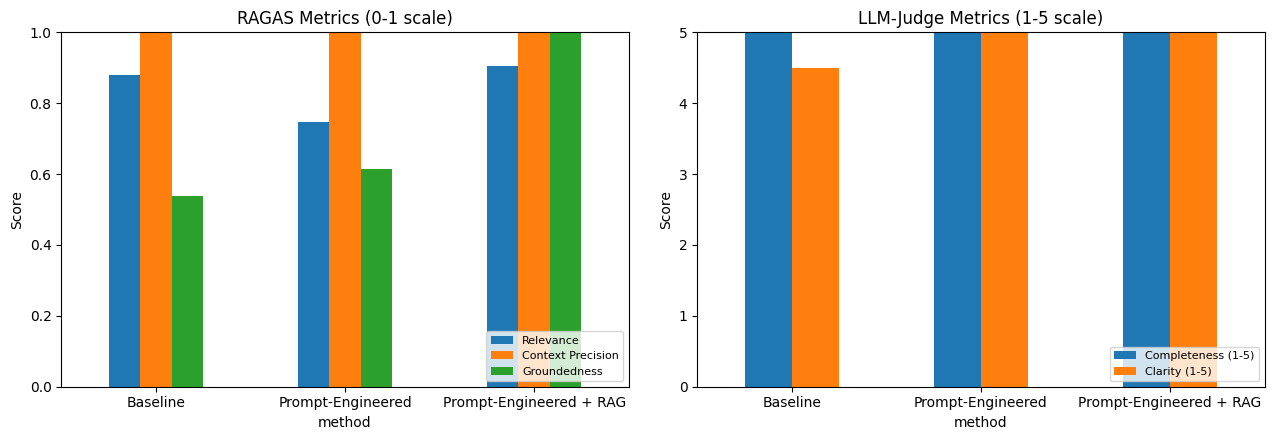

In [34]:
# Visual comparison across all five dimensions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

final_summary[["Relevance", "Context Precision", "Groundedness"]].plot(
    kind="bar", ax=axes[0], rot=0, ylim=(0, 1)
)
axes[0].set_title("RAGAS Metrics (0-1 scale)")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right", fontsize=8)

final_summary[["Completeness (1-5)", "Clarity (1-5)"]].plot(
    kind="bar", ax=axes[1], rot=0, ylim=(0, 5)
)
axes[1].set_title("LLM-Judge Metrics (1-5 scale)")
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


### Evaluation Discussion

**Groundedness (Faithfulness):**  
The results show that the Prompt-Engineered + RAG method achieved the highest groundedness score (1.00), indicating that all generated answers were fully supported by the retrieved HR policy documents. Interestingly, Prompt-Engineered (0.615) scored somewhat higher on faithfulness than the Baseline (0.537) in this run — likely because the prompt-engineered version's explicit instruction to flag uncertainty rather than invent specifics made its claims more cautious and verifiable, even without access to the handbook. Both remain far below RAG's grounding, since neither had access to the actual source document.

**Relevance:**  
All three methods produced relevant answers, with scores of 0.88 for Baseline, 0.75 for Prompt-Engineered, and 0.90 for Prompt-Engineered + RAG. The RAG approach achieved the highest relevance because it combined effective prompting with document retrieval, allowing responses to better match the user's questions.

**Context Precision:**  
Context Precision remained constant at 1.00 for all three methods because the same retrieval mechanism was used throughout the evaluation. This indicates that the retrieved document chunks were consistently relevant, and the observed performance differences were due to how each method utilized the available context rather than differences in retrieval quality.

**Completeness:**  
The LLM Judge assigned the maximum completeness score (5/5) to all three methods. This indicates that each approach provided sufficiently complete answers to the evaluation questions. Although completeness remained the same, the RAG-based responses were more strongly supported by evidence from the HR policy documents.

**Clarity:**  
Prompt-Engineered and Prompt-Engineered + RAG both received the maximum clarity score (5/5), while Baseline scored slightly lower at 4.5/5. The structured prompting used in the notebook produced clear and easy-to-understand responses across all approaches, with RAG maintaining this clarity while also improving factual grounding.

**Limitation:**
All three methods received the maximum completeness score (5/5) from the LLM judge, and two of the three (Prompt-Engineered and Prompt-Engineered + RAG) also received the maximum clarity score (5/5), with Baseline close behind at 4.5/5. This near-ceiling clustering is a weaker signal than the RAGAS metrics (which showed a meaningful 0.48–1.00 spread on faithfulness). This suggests a ceiling effect in the judge rubric rather than genuinely identical quality across methods — likely because the rubric doesn't give the judge concrete anchors distinguishing a "3" from a "5." A stronger version of this evaluation would calibrate the judge with a few labeled example answers at each score level, or use a more granular 1–10 scale.

**Overall:**  
Overall, the Prompt-Engineered + RAG approach achieved the best performance. It produced the highest relevance (0.90) and perfect groundedness (1.00) while maintaining high context precision (1.00) and perfect LLM Judge scores for completeness and clarity. These results demonstrate that combining prompt engineering with retrieval produces responses that are both well-structured and factually supported, making it the most effective method among the three evaluated.

## Part F — Actionable Insights and Recommendations

### Key Findings

- A baseline LLM without access to the HR handbook can generate fluent and plausible responses, but it cannot reliably provide organization-specific or verifiable answers because it lacks access to the company's documented HR policies.
- Prompt engineering (role prompting, structured output, and explicit uncertainty instructions) improves the clarity and organization of responses, but it cannot fully address the issue of factual grounding when the model does not have access to the relevant documents.
- The Prompt-Engineered + RAG approach achieved the best overall performance. By retrieving relevant sections from the HR handbook before generating responses, it produced answers that were more accurate, traceable to source documents, and better grounded in company policy. This was reflected in the evaluation results, where the RAG approach achieved the highest relevance score (0.90) and perfect groundedness (1.00).

### Practical Recommendations

- Deploy the Prompt-Engineered + RAG configuration as the production approach for an HR question-answering assistant instead of using the baseline or prompt-only methods.
- Periodically review the retrieval parameters (such as chunk size and top-k retrieval) whenever the HR handbook is updated to ensure retrieval quality remains high.
- Display the retrieved source passages alongside generated answers so that employees and HR staff can easily verify responses against the official policy documents. This increases transparency and user trust.
- Log responses with low confidence or responses indicating that the required information is unavailable. These cases should be reviewed by HR to identify missing policies or improve the retrieval system.

### Benefits for HR Teams and Employees

- Reduces repetitive HR inquiries related to documented policies and procedures, allowing HR professionals to focus on more complex employee matters.
- Provides employees with consistent, evidence-based answers that are directly supported by official HR documentation.
- Improves the accessibility of HR policies by allowing employees to obtain accurate information quickly through natural language questions.
- Increases confidence in AI-generated responses by providing supporting evidence from the HR handbook.

### Risks, Limitations, and Responsible Use

- This system is intended as a decision-support system and should not replace HR professionals, legal advisors, or employee relations specialists, particularly for sensitive issues such as harassment investigations, disciplinary actions, or employment termination.
- The quality of generated responses depends entirely on the accuracy, completeness, and currency of the indexed HR handbook. If relevant information is not present in the source documents, the system should clearly state that the information is unavailable rather than generating unsupported answers.
- HR policies may vary across organizations, industries, and legal jurisdictions. Therefore, this prototype should not be applied to other organizations without replacing or updating the underlying document collection.
- Confidential, sensitive, or personally identifiable employee information should never be included in the indexed document set to ensure privacy and regulatory compliance.

### Possible Improvements and Future Work

- Expand the knowledge base by incorporating multiple HR-related documents, such as employee benefits guides, code of conduct policies, leave policies, and compliance manuals, to support more comprehensive retrieval.
- Develop a human-annotated reference dataset ("gold standard") to complement the current reference-free RAGAS metrics and LLM-Judge evaluation.
- Include citations to the specific HR handbook section or policy number within generated responses to improve traceability and auditability.
- Evaluate alternative embedding models, chunking strategies, and retrieval techniques to further improve retrieval accuracy and answer quality.
- Conduct a pilot study with HR professionals and employees to collect structured feedback on usability, response quality, and overall user satisfaction before deploying the system in a production environment.